# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [1]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader

# Импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Устройство: GPU, если есть, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

Устройство: cpu


## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [2]:
# TODO: загрузите MNIST через torchvision.datasets

# Преобразование: PIL → тензор + нормализация по статистикам Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor()
])

# Обучающая и тестовая части
full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Делим train на train и val
train_data, val_data = random_split(
    full_train, [55000, 5000],
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

# DataLoader'ы
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

# Названия классов
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.54MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.3MB/s]


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Первый свёрточный блок: свёртка → ReLU → MaxPool
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Второй свёрточный блок: свёртка → ReLU → MaxPool
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Классификатор: flatten → скрытый слой → выходной слой
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

In [5]:
# TODO: обучите модель на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

# Создаём модель, оптимизатор и функцию потерь
model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Обучаем 3 эпохи
for epoch in range(3):
    loss, accuracy = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, accuracy={accuracy:.4f}")

# Точность на чистых данных
clean_loss, clean_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Epoch 1: loss=0.5000, accuracy=0.8197
Epoch 2: loss=0.3127, accuracy=0.8886
Epoch 3: loss=0.2726, accuracy=0.9008
Clean accuracy: 0.8960


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$ x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \text{sign}$nabla_x L$theta, x^t, y)) \right) $

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

**PGD** — это многошаговая версия FGSM. Вместо одного большого шага по знаку градиента PGD делает много маленьких шагов и после каждого возвращает возмущение в допустимую область. Это гораздо сильнее одношаговой атаки, потому что модель успевает «почувствовать» ландшафт функции потерь и точнее найти максимум лосса внутри ε-шара.

$$x^{t+1} = \Pi_{x+S}\left(x^t + \alpha \cdot \text{sign}\left(\nabla_x L(\theta, x^t, y)\right)\right)$$

Здесь:
- $x^t$ — adversarial-пример на итерации $t$,
- $\alpha$ — размер шага,
- $\Pi$ — операция проекции,
- $S$ — допустимое множество возмущений (L∞-шар радиуса $\varepsilon$).

После каждого шага возмущение может выйти за границы допустимого множества. Проекция возвращает его обратно. В случае L∞-ограничения это означает: обрезать каждое значение возмущения по амплитуде до $\pm\varepsilon$. Дополнительно нужно ограничить сам пиксель диапазоном $[0, 1]$ — это отдельная проекция.

Если всегда начинать с нулевого возмущения, PGD может попасть в плохой локальный максимум. Случайный старт внутри ε-шара даёт разные начальные точки и в среднем делает атаку сильнее. Именно поэтому в adversarial training используют PGD со случайным стартом — это даёт более крепкую защиту.


**S** — это ε-шар, то есть множество всех возмущений с амплитудой не больше ε. Запись $\Pi_{x+S}$ означает проекцию на множество «исходный x плюс допустимое возмущение».

**Проекция на x + S** -  взять текущую точку, вычислить, насколько она отклонилась от исходного x, и если отклонение вышло за ε, вернуть его обратно. Это отклонение и есть **delta**:

$$\delta = x^t - x$$

То есть **delta** — это возмущение, разница между текущим adversarial-примером и оригиналом.

- Мы храним и обновляем не сам $x^t$, а именно $\delta$.
- После шага градиента $\delta$ может стать больше $\varepsilon$ по модулю — тогда мы обрезаем его.
- Дополнительно нужно следить, чтобы итоговый пиксель $x + \delta$ не вышел за пределы допустимого диапазона $[0, 1]$ — это вторая проекция.
- В итоге $x^t = x + \delta$ всегда лежит в ε-шаре вокруг исходного $x$, а сам пиксель — в $[0, 1]$.

In [6]:
# TODO: реализуйте функцию PGD-атаки
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    # 1. Инициализация возмущения delta
    # Если randomize=True — начинаем со случайного шума внутри ε-шара.
    # Это называется random start и делает атаку сильнее: разные начальные
    # точки дают разные локальные максимумы, и в среднем атака находит лучший.
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        # Иначе стартуем с нуля (детерминированный вариант)
        delta = torch.zeros_like(x)

    # Первая проекция: x + delta должно попасть в диапазон [0, 1].
    # Иначе с самого начала пиксели могут оказаться вне допустимых значений.
    x_adv = torch.clamp(x + delta, 0.0, 1.0)

    # 2. Основной цикл PGD
    for _ in range(num_iter):
        # Отсоединяем x_adv от прошлого графа и включаем отслеживание градиента.
        # Так PyTorch будет считать градиент именно по текущему x_adv.
        x_adv = x_adv.detach().requires_grad_(True)

        # Прямой проход: получаем логиты модели на текущем adversarial-примере
        logits = model(x_adv)
        # Считаем лосс между логитами и истинными метками
        loss = criterion(logits, y)

        # Обнуляем старые градиенты
        model.zero_grad()
        # Обратный проход: получаем градиент лосса по x_adv
        loss.backward()

        # Отключаем градиенты для шага обновления и проекции
        with torch.no_grad():
            # Обновляем возмущение по знаку градиента.
            # delta = x_adv - x — это текущее возмущение.
            # К нему прибавляем шаг alpha по знаку градиента.
            # Знак берём, чтобы шаг был максимальным при ограничении L∞.
            delta = x_adv - x + alpha * x_adv.grad.sign()

            # 3. Проекция на ε-шар.
            # Обрезаем каждое значение delta до диапазона [-epsilon, epsilon],
            # чтобы ни один пиксель не отклонился от оригинала больше чем на ε.
            delta = torch.clamp(delta, -epsilon, epsilon)

            # Проекция на допустимый диапазон пикселей.
            # x + delta может выйти за [0, 1] из-за шага, поэтому ограничиваем.
            x_adv = torch.clamp(x+  delta, 0.0, 1.0)

    # Возвращаем финальный adversarial-пример без графа вычислений
    return x_adv.detach()

### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [7]:
# TODO: реализуйте FGSM (напоминание из предыдущей лабораторной)

def fgsm_attack(model, x, y, epsilon, criterion):
    # Копия входа с градиентом
    x_adv = x.clone().detach().requires_grad_(True)

    # Прямой проход и лосс
    logits = model(x_adv)
    loss = criterion(logits, y)

    # Обратный проход: получаем градиент лосса по входу
    model.zero_grad()
    loss.backward()

    # Один шаг по знаку градиента
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    # Ограничиваем значения пикселей [0, 1]
    return torch.clamp(x_adv, 0.0, 1.0).detach()

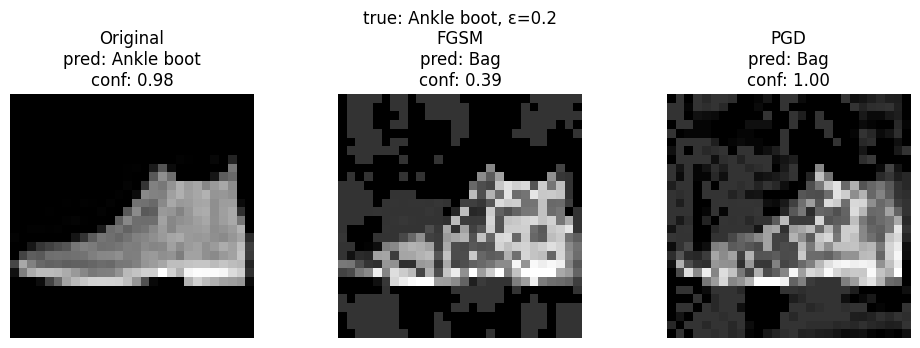

In [8]:
# TODO: выберите тестовый пример
# TODO: примените fgsm_attack и pgd_attack с epsilon=0.2 (для PGD: alpha=0.02, num_iter=40)
# TODO: постройте визуализацию из 3 подграфиков с предсказаниями модели

# Берём один тестовый пример
model.eval()
for x_batch, y_batch in test_loader:
    break

x0 = x_batch[0:1].to(device)
y0 = y_batch[0:1].to(device)

# Бюджет атаки
epsilon = 0.2

# FGSM: один шаг
x_fgsm = fgsm_attack(model, x0, y0, epsilon, criterion)

# PGD: 40 маленьких шагов, alpha = 0.02
x_pgd = pgd_attack(model, x0, y0, epsilon, alpha=0.02, num_iter=40, criterion=criterion)

# Считаем предсказания и уверенность модели через softmax
with torch.no_grad():
    # Прогоняем все три версии через модель
    logits_clean = model(x0)
    logits_fgsm = model(x_fgsm)
    logits_pgd = model(x_pgd)

    # Softmax превращает логиты в вероятности
    probs_clean = F.softmax(logits_clean, dim=1)[0]
    probs_fgsm = F.softmax(logits_fgsm, dim=1)[0]
    probs_pgd = F.softmax(logits_pgd, dim=1)[0]

    # Предсказанный класс — argmax вероятностей
    prediction_clean = probs_clean.argmax().item()
    prediction_fgsm = probs_fgsm.argmax().item()
    prediction_pgd = probs_pgd.argmax().item()

    # Уверенность — вероятность предсказанного класса
    confidence_clean = probs_clean[prediction_clean].item()
    confidence_fgsm = probs_fgsm[prediction_fgsm].item()
    confidence_pgd = probs_pgd[prediction_pgd].item()

# Визуализация: оригинал, FGSM, PGD
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].imshow(x0[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\npred: {class_names[prediction_clean]}\nconf: {confidence_clean:.2f}")

axes[1].imshow(x_fgsm[0, 0].cpu(), cmap='gray')
axes[1].set_title(f"FGSM\npred: {class_names[prediction_fgsm]}\nconf: {confidence_fgsm:.2f}")

axes[2].imshow(x_pgd[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"PGD\npred: {class_names[prediction_pgd]}\nconf: {confidence_pgd:.2f}")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"true: {class_names[y0.item()]}, ε={epsilon}")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

**Мрй ответ**: Визуально возмущения FGSM и PGD почти не отличаются — оба выглядят как шум поверх картинки, и глаз разницы не ловит. Разница проявляется в уверенности модели: на FGSM-примере предсказание Bag с confidence 0.39 (модель колеблется), а на PGD-примере — то же Bag, но с confidence 1.00 (модель уверена). То есть при одинаковом ε PGD меняет предсказание надёжнее: он делает 40 итераций и точнее находит максимум лосса внутри ε-шара, тогда как FGSM делает один шаг и часто попадает в «пограничную» зону.

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

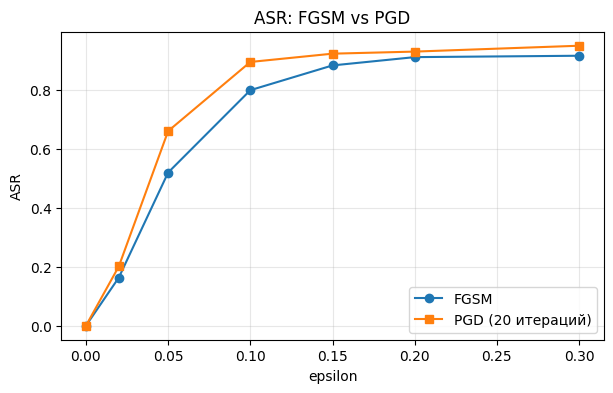

In [9]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки

def evaluate_asr(model, loader, attack_function, criterion, n_batches=10, **attack_kwargs):
    # Режим оценки
    model.eval()
    total, fooled = 0, 0

    for i, (x, y) in enumerate(loader):
        # Ограничиваем число батчей для скорости
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)

        # Предсказание на чистом примере
        with torch.no_grad():
            prediction_clean = model(x).argmax(1)

        # Строим adversarial-пример через переданную функцию атаки
        x_adv = attack_function(model, x, y, criterion=criterion, **attack_kwargs)

        # Предсказание на adversarial
        with torch.no_grad():
            prediction_adv = model(x_adv).argmax(1)

        # Считаем, у кого предсказание изменилось
        fooled += (prediction_adv != prediction_clean).sum().item()
        total += y.size(0)

    return fooled / total

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

# Считаем ASR для FGSM и PGD при каждом ε
asr_fgsm = []
asr_pgd = []
for eps in epsilons:
    if eps == 0.0:
        asr_fgsm.append(0.0)
        asr_pgd.append(0.0)
        continue
    asr_fgsm.append(evaluate_asr(model, test_loader, fgsm_attack, criterion,
                                  n_batches=10, epsilon=eps))
    asr_pgd.append(evaluate_asr(model, test_loader, pgd_attack, criterion,
                                 n_batches=10, epsilon=eps, alpha=eps/4, num_iter=20))

# График
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_fgsm, marker='o', label='FGSM')
plt.plot(epsilons, asr_pgd, marker='s', label='PGD (20 итераций)')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('ASR: FGSM vs PGD')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

num_iter=1: ASR=0.6125
num_iter=2: ASR=0.8328
num_iter=5: ASR=0.9219
num_iter=10: ASR=0.9203
num_iter=20: ASR=0.9215
num_iter=30: ASR=0.9242


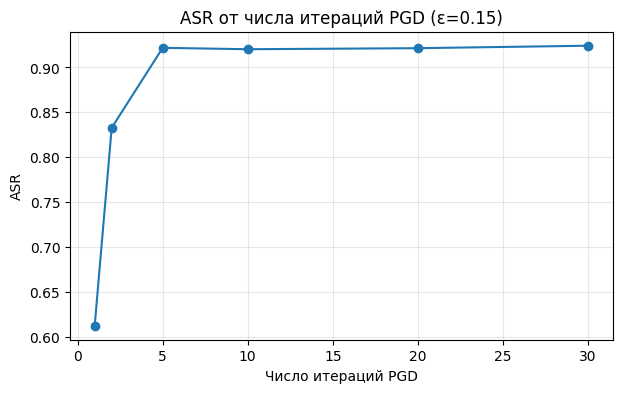

In [10]:
# TODO: рассчитайте ASR для разного числа итераций PGD при фиксированном epsilon=0.15
# TODO: постройте график

epsilon = 0.15
iterations = [1, 2, 5, 10, 20, 30]

asr_by_iterations = []
for num_iter in iterations:
    asr = evaluate_asr(model, test_loader, pgd_attack, criterion,
                       n_batches=10, epsilon=epsilon,
                       alpha=epsilon/4, num_iter=num_iter)
    asr_by_iterations.append(asr)
    print(f"num_iter={num_iter}: ASR={asr:.4f}")

# График
plt.figure(figsize=(7, 4))
plt.plot(iterations, asr_by_iterations, marker='o')
plt.xlabel('Число итераций PGD'); plt.ylabel('ASR')
plt.title(f'ASR от числа итераций PGD (ε={epsilon})')
plt.grid(alpha=0.3); plt.show()

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

**Мой ответ:** ASR выходит на плато примерно после 5 итераций. Первые шаги дают основной прирост, а дальше значения колеблются в пределах шума, и прирост почти нулевой.
Одношаговая линеаризация даёт только нижнюю оценку силы атаки, а настоящий максимум лосса внутри ε-шара требует нескольких шагов. Но их нужно совсем немного — пять уже достаточно, чтобы к нему подойти. Дальнейшие итерации не улучшают результат, потому что PGD уже почти в максимуме.

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L$theta, x+\delta, y) \right] $

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [11]:
# TODO: реализуйте цикл adversarial training
# На каждом батче:
# 1. Постройте x_adv через pgd_attack (5-7 итераций, epsilon=0.15)
# 2. Посчитайте loss на x_adv
# 3. Сделайте шаг оптимизации

adversarial_model = SmallCNN().to(device)
adversarial_optimizer = torch.optim.Adam(adversarial_model.parameters(), lr=0.001)

def train_epoch_adversarial(model, loader, optimizer, criterion, device,
                             epsilon=0.15, alpha=0.03, num_iter=7):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Внутренний максимум: строим adversarial-пример через PGD
        x_adv = pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True)

        # Внешний шаг: обновляем веса на adversarial-примерах
        optimizer.zero_grad()
        logits = model(x_adv)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

# Обучаем 3 эпохи
for epoch in range(3):
    loss, accuracy = train_epoch_adversarial(adversarial_model, train_loader,
                                              adversarial_optimizer, criterion, device)
    print(f"Adv epoch {epoch+1}: loss={loss:.4f}, accuracy={accuracy:.4f}")

Adv epoch 1: loss=1.1453, accuracy=0.5494
Adv epoch 2: loss=0.9349, accuracy=0.6270
Adv epoch 3: loss=0.8653, accuracy=0.6513


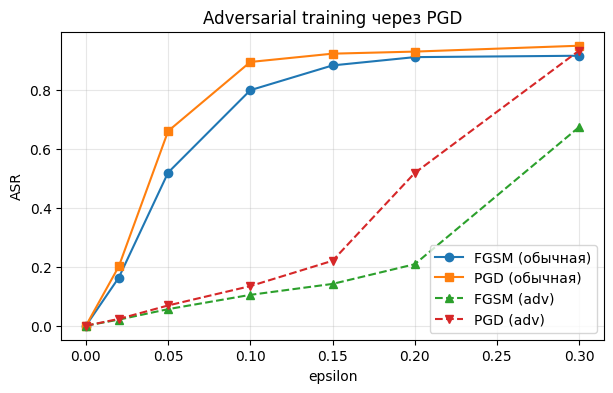

Adv model clean accuracy: 0.8046


In [12]:
# TODO: постройте график ASR(epsilon) для adv_model против FGSM и против PGD
# Сравните на одном графике с результатами обычной модели из п.2.3

# Считаем ASR для adv-модели против FGSM и PGD
asr_fgsm_adversarial = []
asr_pgd_adversarial = []
for eps in epsilons:
    if eps == 0.0:
        asr_fgsm_adversarial.append(0.0)
        asr_pgd_adversarial.append(0.0)
        continue
    asr_fgsm_adversarial.append(evaluate_asr(adversarial_model, test_loader, fgsm_attack,
                                              criterion, n_batches=10, epsilon=eps))
    asr_pgd_adversarial.append(evaluate_asr(adversarial_model, test_loader, pgd_attack,
                                             criterion, n_batches=10, epsilon=eps,
                                             alpha=eps/4, num_iter=20))

# Сравнительный график
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_fgsm, marker='o', label='FGSM (обычная)')
plt.plot(epsilons, asr_pgd, marker='s', label='PGD (обычная)')
plt.plot(epsilons, asr_fgsm_adversarial, marker='^', linestyle='--', label='FGSM (adv)')
plt.plot(epsilons, asr_pgd_adversarial, marker='v', linestyle='--', label='PGD (adv)')
plt.xlabel('epsilon'); plt.ylabel('ASR')
plt.title('Adversarial training через PGD')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Чистая точность adv-модели
adversarial_clean_loss, adversarial_clean_accuracy = evaluate(
    adversarial_model, test_loader, criterion, device)
print(f"Adv model clean accuracy: {adversarial_clean_accuracy:.4f}")

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

**Мой ответ:**:  После adversarial training ASR против PGD снизился в разы, а против FGSM — ещё сильнее. Это согласуется с идеей «универсального первопорядкового противника»: устойчивость к PGD автоматически даёт устойчивость к более слабым атакам. FGSM — это один шаг PGD, поэтому модель, обученная против многошагового противника, легко справляется и с одношаговым. Отсюда и более сильное падение ASR против FGSM.

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:
 
$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

# Атака Carlini & Wagner (C&W)

**C&W** — оптимизационная атака. Вместо движения по знаку градиента она решает задачу минимизации: найти такое возмущение, чтобы модель уверенно предсказала целевой класс, а норма возмущения была как можно меньше.

## Замена переменных

Прямая оптимизация $x_{adv}$ с ограничением $x_{adv} \in [0, 1]$ неудобна. C&W вводит новую переменную $w$ через tanh:

$$x' = \frac{1}{2}(\tanh(w) + 1)$$

При любом $w$ результат $x'$ автоматически лежит в $[0, 1]$. Это снимает необходимость явного clipping.

## Функция потерь на логитах

Основная задача — чтобы целевой класс стал самым вероятным. C&W использует:

$$f(x') = \max\left(\max_{i \neq t} Z(x')_i - Z(x')_t, \; -\kappa\right)$$

где $Z$ — логиты, $t$ — целевой класс, $\kappa$ — параметр confidence. Если $f \le 0$, значит целевой логит превышает все остальные как минимум на $\kappa$.

## Итоговая целевая функция

$$\min_w \left\| \frac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\!\left(\frac{1}{2}(\tanh(w)+1)\right)$$

Первый член — квадрат L2-расстояния до оригинала. Второй — штраф за недостаточную уверенность в целевом классе. Константа $c$ балансирует их.

In [13]:
# TODO: реализуйте функцию C&W L2-атаки
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, learning_rate=0.01):
    model.eval()

    # 1. Замена переменных: w = atanh(2x - 1)
    # Зажимаем x слегка от границ, чтобы atanh не выдал inf
    x_clamped = torch.clamp(x, 1e-6, 1 - 1e-6)
    w = torch.atanh(2 * x_clamped - 1).detach().clone().requires_grad_(True)

    # 2. Оптимизатор Adam по переменной w
    optimizer = torch.optim.Adam([w], lr=learning_rate)

    # Целевая метка
    target = torch.full((x.size(0),), target_class, dtype=torch.long, device=x.device)

    for step in range(num_steps):
        # Получаем x_adv из w
        x_adv = 0.5 * (torch.tanh(w) + 1)

        # Логиты модели
        logits = model(x_adv)

        # 3. f(x') = max(max_other - target_logit, -kappa)
        target_logit = logits.gather(1, target.view(-1, 1)).squeeze(1)
        logits_other = logits.clone()
        # Заменяем целевой логит на -inf, чтобы он не попал в max
        logits_other.scatter_(1, target.view(-1, 1), float('-inf'))
        max_other = logits_other.max(1)[0]
        f_loss = torch.clamp(max_other - target_logit, min=-kappa)

        # Квадрат L2-расстояния до оригинала
        dist_loss = ((x_adv - x) ** 2).view(x.size(0), -1).sum(1)

        # 4. Итоговая функция потерь
        loss = (dist_loss + c * f_loss).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Финальный x_adv
    with torch.no_grad():
        x_adv = 0.5 * (torch.tanh(w) + 1)
    return x_adv.detach()

### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

True: Ankle boot, target: T-shirt

Вероятности на оригинале:
  T-shirt      0.0000
  Trouser      0.0000
  Pullover     0.0000
  Dress        0.0000
  Coat         0.0000
  Sandal       0.0118
  Shirt        0.0000
  Sneaker      0.0121
  Bag          0.0000
  Ankle boot   0.9760 <- true

Вероятности на C&W-примере:
  T-shirt      0.3961 <- target
  Trouser      0.0005
  Pullover     0.0046
  Dress        0.0005
  Coat         0.0013
  Sandal       0.1673
  Shirt        0.1802
  Sneaker      0.0588
  Bag          0.1131
  Ankle boot   0.0777 <- true


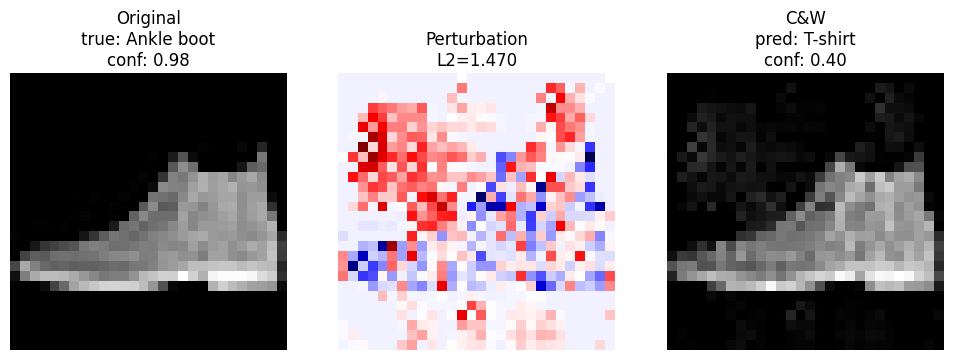

In [14]:
# TODO: выберите пример, задайте target_label
# Ищем пример, где модель уверена в истинном классе — так атаку нагляднее показывать
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        probs = F.softmax(model(x_batch.to(device)), dim=1)
        # Уверенность модели в истинном классе для каждого примера
        confidences = probs.gather(1, y_batch.to(device).view(-1, 1)).squeeze(1)
        # Берём первый пример с уверенностью выше 0.9
        idx = (confidences > 0.9).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            idx = idx[0].item()
            x0 = x_batch[idx:idx+1].to(device)
            y0 = y_batch[idx:idx+1].to(device)
            break

true_class = y0.item()
target_label = (true_class + 1) % 10
print(f"True: {class_names[true_class]}, target: {class_names[target_label]}")

# Вероятности на оригинале
with torch.no_grad():
    probs_clean = F.softmax(model(x0), dim=1)[0]
print("\nВероятности на оригинале:")
for i, p in enumerate(probs_clean):
    marker = " <- true" if i == true_class else ""
    print(f"  {class_names[i]:<12} {p.item():.4f}{marker}")

# C&W атака с увеличенными c и числом шагов — чтобы атака успела сойтись
x_cw = cw_l2_attack(model, x0, target_label, c=10.0, kappa=0.0, num_steps=500, learning_rate=0.05)

# Вероятности на adversarial-примере
with torch.no_grad():
    logits_adv = model(x_cw)
    probs_adv = F.softmax(logits_adv, dim=1)[0]
    prediction_adv = probs_adv.argmax().item()
    confidence_adv = probs_adv[prediction_adv].item()

print("\nВероятности на C&W-примере:")
for i, p in enumerate(probs_adv):
    marker = ""
    if i == target_label:
        marker = " <- target"
    elif i == true_class:
        marker = " <- true"
    print(f"  {class_names[i]:<12} {p.item():.4f}{marker}")

# L2-норма возмущения
l2_norm = ((x_cw - x0) ** 2).sum().sqrt().item()

# Визуализация: оригинал, возмущение, adversarial
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(x0[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\ntrue: {class_names[true_class]}\nconf: {probs_clean[true_class]:.2f}")
axes[1].imshow((x_cw - x0)[0, 0].cpu().numpy(), cmap='seismic')
axes[1].set_title(f"Perturbation\nL2={l2_norm:.3f}")
axes[2].imshow(x_cw[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"C&W\npred: {class_names[prediction_adv]}\nconf: {confidence_adv:.2f}")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

kappa=0: L2=1.941, P(target)=0.229
kappa=0.2: L2=1.965, P(target)=0.263
kappa=0.4: L2=1.983, P(target)=0.289
kappa=0.6: L2=1.980, P(target)=0.309
kappa=0.8: L2=1.997, P(target)=0.341
kappa=1: L2=2.031, P(target)=0.399
kappa=1.2: L2=2.072, P(target)=0.472
kappa=1.4: L2=2.071, P(target)=0.468
kappa=1.6: L2=2.120, P(target)=0.567
kappa=1.8: L2=2.144, P(target)=0.601
kappa=2: L2=2.140, P(target)=0.602
kappa=2.5: L2=2.223, P(target)=0.742
kappa=3: L2=2.302, P(target)=0.827
kappa=3.5: L2=2.360, P(target)=0.869
kappa=4: L2=2.449, P(target)=0.913
kappa=4.5: L2=2.555, P(target)=0.949
kappa=5: L2=2.655, P(target)=0.968
kappa=5.5: L2=2.743, P(target)=0.978
kappa=6: L2=2.861, P(target)=0.987
kappa=6.5: L2=3.000, P(target)=0.992
kappa=7: L2=3.144, P(target)=0.995
kappa=10: L2=4.116, P(target)=1.000
kappa=20: L2=6.079, P(target)=1.000


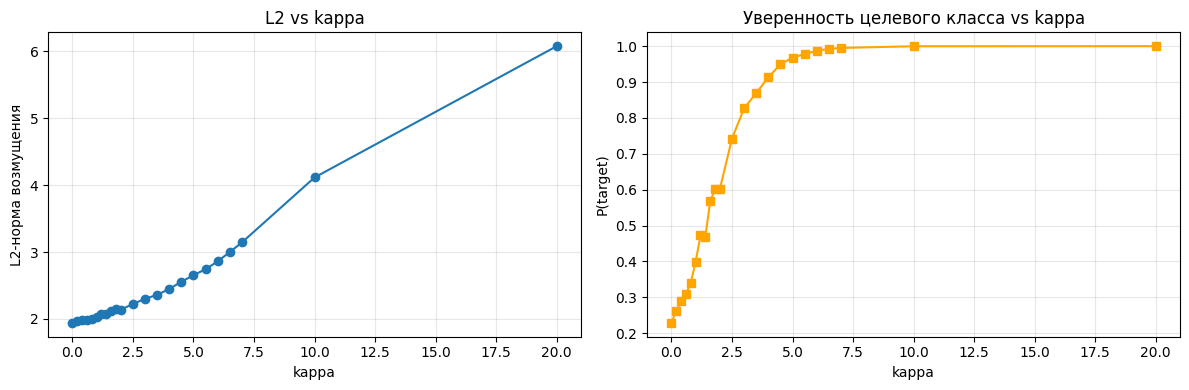

In [27]:
# TODO: постройте атаки для разных значений kappa
# TODO: постройте два графика (L2-норма и confidence целевого класса от kappa)

#kappas = [0, 5, 10, 20, 40]
kappas = [0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 10, 20]
l2_norms = []
target_probabilities = []

for kappa in kappas:
    # Строим C&W с умеренным c, малым lr и большим числом шагов
    # Так оптимизатор не будет пролетать хорошую область и насыщать tanh
    x_cw = cw_l2_attack(model, x0, target_label, c=10.0, kappa=kappa,
                         num_steps=1000, learning_rate=0.005)

    # L2-норма возмущения
    l2 = ((x_cw - x0) ** 2).sum().sqrt().item()
    l2_norms.append(l2)

    # Вероятность целевого класса
    with torch.no_grad():
        probability = F.softmax(model(x_cw), dim=1)[0, target_label].item()
    target_probabilities.append(probability)

    print(f"kappa={kappa}: L2={l2:.3f}, P(target)={probability:.3f}")

# Два графика: L2-норма и вероятность целевого класса в зависимости от kappa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(kappas, l2_norms, marker='o')
axes[0].set_xlabel('kappa'); axes[0].set_ylabel('L2-норма возмущения')
axes[0].set_title('L2 vs kappa'); axes[0].grid(alpha=0.3)

axes[1].plot(kappas, target_probabilities, marker='s', color='orange')
axes[1].set_xlabel('kappa'); axes[1].set_ylabel('P(target)')
axes[1].set_title('Уверенность целевого класса vs kappa'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

**Мой ответ**: . С ростом κ величина возмущения увеличивается, и вероятность целевого класса тоже растёт. При малых κ изменения слабые, при больших — заметные. Когда P(target) подходит к единице, дальнейший рост κ уже не помогает атаке, но L2 продолжает увеличиваться.

Это следует из формулы f(x') = max(max_other − target_logit, −κ). κ задаёт минимальный запас уверенности: чем он больше, тем глубже нужно увести пример в область целевого класса. При κ = 0 достаточно границы решения, при больших κ приходится сильнее искажать пиксели. Поэтому L2 растёт. Когда модель уже максимально уверена, дополнительный запас ничего не даёт по существу, но формула всё равно его требует — отсюда рост L2 без пользы.



## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

# Часть IV. Jacobian-based Saliency Map Attack (JSMA)

## 4.1. Теория и реализация

**Что такое JSMA.** JSMA (Jacobian-based Saliency Map Attack) — это целевая атака, которая меняет **минимум пикселей**, а не все подряд. Идея: для классификации важны не все пиксели одинаково. Если найти несколько пикселей, которые сильнее всего влияют на предсказание, можно изменить только их — и атака получится очень разреженной.

Это отличает JSMA от PGD и C&W. PGD меняет все пиксели на маленькую величину. C&W тоже распределяет возмущение по всей картинке, но старается, чтобы L2-норма была маленькой. JSMA же работает в другой норме — L0, то есть считает **число изменённых пикселей** и старается его минимизировать. В результате возмущение может быть большим по амплитуде, но затронуть всего несколько десятков точек из 784.

**Что такое якобиан.** Якобиан — это матрица частных производных выходов модели по входам. Для нашей задачи это выглядит так:

$$J_{c,ij} = \frac{\partial p_c}{\partial x_{ij}}$$

где `p_c` — вероятность класса c (после softmax), `x_ij` — пиксель в позиции (i, j). Значение `J_{c,ij}` показывает, как изменится вероятность класса c, если чуть-чуть увеличить пиксель (i, j).

У нас 10 классов и 784 пикселя, значит, якобиан имеет форму `[10, 1, 28, 28]`.

**Saliency-карта.** Нам нужны пиксели, которые одновременно:

- увеличивают вероятность целевого класса;
- уменьшают вероятности всех остальных классов.

Из этого и строится saliency-карта:

$$S[i,j] = \frac{\partial p_t}{\partial x_{ij}} \cdot \left| \sum_{c \neq t} \frac{\partial p_c}{\partial x_{ij}} \right| \cdot \mathbb{1}\!\left[\sum_{c \neq t} \frac{\partial p_c}{\partial x_{ij}} < 0\right]$$

Разберём по частям.

- `∂p_t/∂x_ij` — градиент целевого класса. Если положительный, то увеличение пикселя повышает вероятность целевого класса. Если отрицательный — понижает, и такой пиксель нам не подходит.
- `Σ_{c ≠ t} ∂p_c/∂x_ij` — суммарный градиент остальных классов. Если отрицательный, значит увеличение пикселя уменьшает суммарную вероятность всех остальных классов. Это тоже хорошо.
- `|·|` — модуль, чтобы произведение двух отрицательных давало положительное число.
- `𝟙[· < 0]` — индикатор, оставляющий только те пиксели, где суммарный градиент остальных классов строго отрицательный.

В итоге большие значения saliency получают те пиксели, которые одновременно «тянут» пример в сторону целевого класса и «отталкивают» от всех остальных. Именно их и надо менять.

**Как работает атака.** Итеративно:

1. Проверяем текущее предсказание. Если модель уже даёт целевой класс — выходим.
2. Считаем якобиан.
3. Строим saliency-карту.
4. Исключаем пиксели, которые уже меняли раньше (чтобы не увеличивать один и тот же несколько раз).
5. Исключаем пиксели, близкие к 1 (они уже почти белые, дальше увеличивать некуда).
6. Находим пиксель с максимальной saliency.
7. Увеличиваем его значение на θ (обычно до предела, например до 1.0).
8. Помечаем как изменённый.
9. Повторяем, пока не достигнем целевого класса или лимита `max_pixels`.

**Почему именно увеличение, а не уменьшение.** Классическая формулировка JSMA рассматривает увеличение пикселей. Для MNIST и Fashion-MNIST это работает: пиксели светлого фона увеличиваются, и это сдвигает активации в нужную сторону. В принципе можно было бы рассматривать и уменьшение, но тогда нужно было бы строить другую saliency-карту.

**Функция compute_jacobian.** Здесь мы считаем якобиан. Для каждого из 10 классов берём градиент вероятности этого класса по входу. Используем `torch.autograd.grad` с `grad_outputs`, который говорит, по какому выходу считать производную. Собираем все 10 градиентов в один тензор формы `[10, 1, 28, 28]`.

In [16]:
# TODO: реализуйте функцию вычисления якобиана
def compute_jacobian(model, x, num_classes=10):
    # x: [1, 1, 28, 28] с градиентом
    x = x.clone().detach().requires_grad_(True)

    # Логиты и вероятности
    logits = model(x)
    probabilities = F.softmax(logits, dim=1)

    gradients = []
    for class_index in range(num_classes):
        # grad_outputs с единицей на позиции class_index — так мы считаем
        # градиент именно вероятности этого класса по входу
        grad_outputs = torch.zeros_like(probabilities)
        grad_outputs[0, class_index] = 1.0

        # Градиент вероятности класса по входу
        gradient_class = torch.autograd.grad(
            outputs=probabilities,
            inputs=x,
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=False
        )[0]
        gradients.append(gradient_class)

    # Складываем в тензор формы [num_classes, 1, 28, 28]
    jacobian = torch.stack(gradients, dim=0).squeeze(1)
    return jacobian.detach()

In [17]:
# TODO: реализуйте функцию JSMA-атаки
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    model.eval()

    # Копия примера и маска изменённых пикселей
    x_adv = x.clone().detach()
    modified = torch.zeros_like(x_adv, dtype=torch.bool)
    pixels_changed = 0

    for step in range(max_pixels):
        # Если модель уже предсказывает целевой класс — выходим
        with torch.no_grad():
            prediction = model(x_adv).argmax(1).item()
        if prediction == target_class:
            break

        # Якобиан по входу: [10, 1, 28, 28]
        jacobian = compute_jacobian(model, x_adv)

        # Градиент целевого класса
        target_gradient = jacobian[target_class]
        # Суммарный градиент остальных классов
        other_gradient = jacobian.sum(dim=0) - target_gradient

        # Saliency: только пиксели, где градиент других классов отрицательный
        mask_negative = (other_gradient < 0).float()
        saliency = target_gradient * mask_negative * torch.abs(other_gradient)

        # Исключаем уже изменённые и насыщенные пиксели
        saliency = saliency.squeeze(0)
        saliency[modified[0, 0]] = -float('inf')
        saturated = x_adv[0, 0] >= 0.99
        saliency[saturated] = -float('inf')

        # Индекс пикселя с максимальной saliency
        flat_index = saliency.view(-1).argmax().item()
        row = flat_index // 28
        col = flat_index % 28

        # Если все пиксели исчерпаны — прерываемся
        if saliency.view(-1)[flat_index].item() == -float('inf'):
            break

        # Насыщаем пиксель: увеличиваем на theta, но не больше 1
        with torch.no_grad():
            x_adv[0, 0, row, col] = min(1.0, x_adv[0, 0, row, col].item() + theta)

        # Помечаем как изменённый
        modified[0, 0, row, col] = True
        pixels_changed += 1

    return x_adv.detach(), pixels_changed

### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).


Вероятности на JSMA-примере:
  T-shirt      0.3020 <- target
  Trouser      0.0001
  Pullover     0.0025
  Dress        0.0001
  Coat         0.0005
  Sandal       0.0369
  Shirt        0.0874
  Sneaker      0.1242
  Bag          0.1770
  Ankle boot   0.2693 <- true

Изменённых пикселей: 60


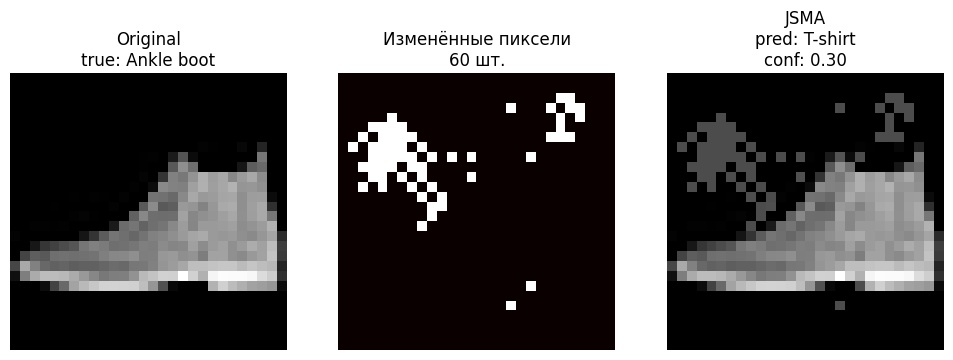

In [18]:
# TODO: примените jsma_attack к тому же примеру и target_label из части III
# TODO: визуализируйте результат (3 подграфика)

# Применяем JSMA к тому же примеру и тому же target_label
x_jsma, number_of_pixels = jsma_attack(model, x0, target_label, max_pixels=100, theta=0.3)

# Вероятности на adversarial-примере
with torch.no_grad():
    probs_jsma = F.softmax(model(x_jsma), dim=1)[0]
    prediction_jsma = probs_jsma.argmax().item()
    confidence_jsma = probs_jsma[prediction_jsma].item()

print("\nВероятности на JSMA-примере:")
for i, p in enumerate(probs_jsma):
    marker = ""
    if i == target_label:
        marker = " <- target"
    elif i == true_class:
        marker = " <- true"
    print(f"  {class_names[i]:<12} {p.item():.4f}{marker}")
print(f"\nИзменённых пикселей: {number_of_pixels}")

# Карта изменений
difference = (x_jsma - x0).abs()[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(x0[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\ntrue: {class_names[true_class]}")
axes[1].imshow(difference, cmap='hot')
axes[1].set_title(f"Изменённые пиксели\n{number_of_pixels} шт.")
axes[2].imshow(x_jsma[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"JSMA\npred: {class_names[prediction_jsma]}\nconf: {confidence_jsma:.2f}")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


Вероятности на JSMA-примере:
  T-shirt      0.0000
  Trouser      0.0000
  Pullover     0.0000
  Dress        0.0000
  Coat         0.0000
  Sandal       0.0054
  Shirt        0.0000
  Sneaker      0.5182 <- target
  Bag          0.0004
  Ankle boot   0.4759 <- true

Изменённых пикселей: 8


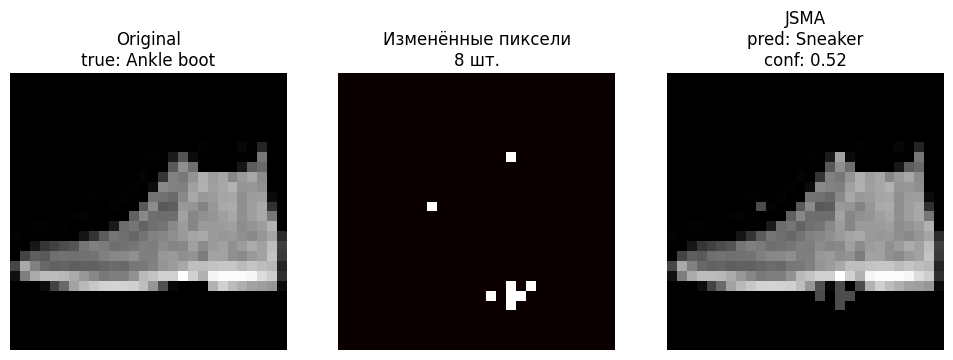

In [19]:
# Применяем JSMA к тому же примеру и тому же target_label
x_jsma, number_of_pixels = jsma_attack(model, x0, 7, max_pixels=100, theta=0.3)

# Вероятности на adversarial-примере
with torch.no_grad():
    probs_jsma = F.softmax(model(x_jsma), dim=1)[0]
    prediction_jsma = probs_jsma.argmax().item()
    confidence_jsma = probs_jsma[prediction_jsma].item()

print("\nВероятности на JSMA-примере:")
for i, p in enumerate(probs_jsma):
    marker = ""
    if i == 7:
        marker = " <- target"
    elif i == true_class:
        marker = " <- true"
    print(f"  {class_names[i]:<12} {p.item():.4f}{marker}")
print(f"\nИзменённых пикселей: {number_of_pixels}")

# Карта изменений
difference = (x_jsma - x0).abs()[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(x0[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Original\ntrue: {class_names[true_class]}")
axes[1].imshow(difference, cmap='hot')
axes[1].set_title(f"Изменённые пиксели\n{number_of_pixels} шт.")
axes[2].imshow(x_jsma[0, 0].cpu(), cmap='gray')
axes[2].set_title(f"JSMA\npred: {class_names[prediction_jsma]}\nconf: {confidence_jsma:.2f}")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

**Мой ответ**: Для успешной атаки потребовалось изменить 8 пикселей из 784 пикселей изображения. Остальные пиксели остались нетронутыми. Это главное преимущество JSMA: атака меняет минимум точек, но каждую сдвигает сильно, и этого хватает, чтобы модель переключилась на целевой класс. 

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [20]:
# TODO: реализуйте функцию целевой PGD-атаки (минимизация loss к целевому классу вместо максимизации к истинному)
#Нам нужна целевая версия PGD, чтобы сравнивать с C&W и JSMA (обе целевые). Обычная PGD максимизирует лосс по истинному
# классу, целевая — минимизирует лосс по целевому классу. Значит, шаг делается не по знаку градиента, а против него.

def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    # Возмущение инициализируем нулём
    delta = torch.zeros_like(x)
    x_adv = x.clone().detach()

    # Целевая метка для всего батча
    target_tensor = torch.full((x.size(0),), target, dtype=torch.long, device=x.device)

    for _ in range(num_iter):
        # Включаем градиент по входу
        x_adv = x_adv.detach().requires_grad_(True)

        # Логиты и лосс по ЦЕЛЕВОМУ классу
        logits = model(x_adv)
        loss = criterion(logits, target_tensor)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Целевая атака: идём ПРОТИВ градиента, чтобы уменьшить лосс по цели
            delta = x_adv - x - alpha * x_adv.grad.sign()
            # Проекция на ε-шар
            delta = torch.clamp(delta, -epsilon, epsilon)
            # Проекция на [0, 1]
            x_adv = torch.clamp(x + delta, 0.0, 1.0)

    return x_adv.detach()

In [28]:
# TODO: постройте атаки всеми тремя методами для одного примера и одного target_label
# TODO: соберите результаты в pandas DataFrame (метод, успех, предсказание, L2, Linf, число пикселей)
# TODO: сохраните таблицу в CSV

def attack_metrics(x_original, x_attacked, target_class, model):
    # Предсказание модели на adversarial-примере
    with torch.no_grad():
        prediction = model(x_attacked).argmax(1).item()

    # Успех: предсказан именно целевой класс
    success = prediction == target_class

    # Возмущение
    difference = x_attacked - x_original

    # L2-норма: корень из суммы квадратов всех отклонений
    l2_norm = difference.view(-1).norm(2).item()

    # L∞-норма: максимум абсолютного отклонения по всем пикселям
    linf_norm = difference.abs().max().item()

    # Число изменённых пикселей: считаем только те, где |изменение| > 1e-3
    changed = (difference.abs() > 1e-3).sum().item()

    return success, prediction, l2_norm, linf_norm, changed


# Фиксируем бюджет для PGD
epsilon = 0.15

# Целевая PGD
x_pgd_targeted = pgd_targeted(model, x0, target_label, epsilon,
                               alpha=epsilon/4, num_iter=40, criterion=criterion)

# C&W
x_cw = cw_l2_attack(model, x0, target_label, c=10.0, kappa=0.0,
                     num_steps=500, learning_rate=0.01)

# JSMA на том же таргете, что и остальные
x_jsma, number_of_pixels_jsma = jsma_attack(model, x0, target_label,
                                              max_pixels=150, theta=0.5)

# Собираем метрики для каждой атаки
results = []
for name, x_attacked in [
    ('PGD targeted', x_pgd_targeted),
    ('C&W L2', x_cw),
    ('JSMA', x_jsma)
]:
    success, prediction, l2, linf, changed = attack_metrics(x0, x_attacked, target_label, model)
    results.append({
        'method': name,
        'target': class_names[target_label],
        'success': success,
        'prediction': class_names[prediction],
        'L2': round(l2, 4),
        'Linf': round(linf, 4),
        'pixels_changed': changed
    })

comparison_table = pd.DataFrame(results)
print(comparison_table)
comparison_table.to_csv('attack_comparison.csv', index=False)

         method   target  success prediction      L2   Linf  pixels_changed
0  PGD targeted  T-shirt     True    T-shirt  3.0623  0.150             588
1        C&W L2  T-shirt     True    T-shirt  2.0942  0.549             478
2          JSMA  T-shirt     True    T-shirt  3.0414  0.500              37


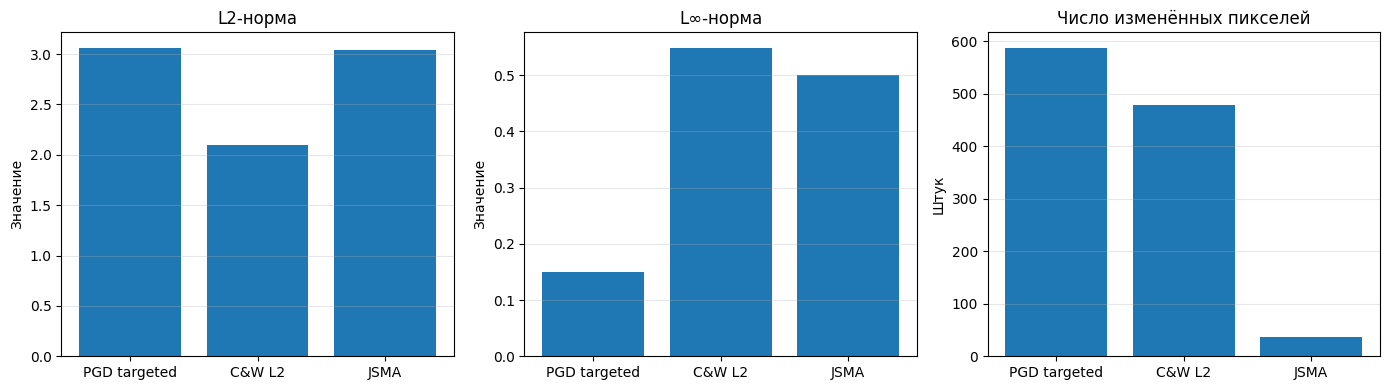

In [29]:
# TODO: постройте столбчатую диаграмму из 3 подграфиков (L2, Linf, число изменённых пикселей)
# для трёх методов

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = comparison_table['method'].tolist()

# L2-норма
axes[0].bar(methods, comparison_table['L2'])
axes[0].set_title('L2-норма')
axes[0].set_ylabel('Значение')
axes[0].grid(alpha=0.3, axis='y')

# L∞-норма
axes[1].bar(methods, comparison_table['Linf'])
axes[1].set_title('L∞-норма')
axes[1].set_ylabel('Значение')
axes[1].grid(alpha=0.3, axis='y')

# Число изменённых пикселей
axes[2].bar(methods, comparison_table['pixels_changed'])
axes[2].set_title('Число изменённых пикселей')
axes[2].set_ylabel('Штук')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

**Мой ответ**:  Наименьшую L2-норму дал C&W, наименьшее число изменённых пикселей — JSMA, а наименьшую L∞-норму — PGD.

Это связано с тем, какую норму каждая атака оптимизирует по своей природе. C&W напрямую минимизирует суммарное расстояние до оригинала, поэтому у него самая маленькая L2-норма. JSMA меняет пиксели по одному и стремится затронуть их как можно меньше, поэтому у него минимум изменённых точек, но каждая сдвигается сильно. PGD ограничивает сверху изменение каждого пикселя бюджетом ε — поэтому у него самая маленькая L∞-норма. При этом PGD не заботится о разреженности: он трогает почти всё изображение, поэтому число изменённых пикселей большое, а L2 накапливается.

Итог: нет одной лучшей атаки. Каждая оптимизирует свою норму и потому выигрывает по своему критерию.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

**Мой ответ:** PGD называют универсальным первопорядковым противником, потому что он напрямую приближает максимум лосса внутри допустимого шара. Он сходится к самой сильной атаке среди методов, использующих градиент первого порядка. Если модель устойчива к PGD, она автоматически устойчива и к более слабым первопорядковым атакам вроде FGSM. Именно поэтому PGD стал стандартом для adversarial training: он даёт максимальную защиту на единицу затрат в этом классе.

C&W используют как эталон для проверки защитных механизмов. Он ищет минимальное возмущение, которое переводит пример в целевой класс, и потому находит слабые места, которые другие атаки пропускают. Если защита проигрывает C&W, это серьёзный сигнал. C&W дороже по вычислениям, поэтому в обучении его почти не применяют — только для оценки.

JSMA ценен разреженностью и интерпретируемостью. Он меняет минимум пикселей, и по карте saliency видно, какие признаки модель считает важными. Это делает его удобным не только для атак, но и для анализа моделей.

По сценариям: для изображений высокого разрешения и табличных данных лучше подходят PGD и C&W. Для систем обнаружения вторжений и задач, где важна незаметность изменения минимума признаков, предпочтительнее JSMA. C&W универсален там, где нужно найти максимально экономное возмущение и есть время на оптимизацию.

Общий вывод: нет одной лучшей атаки. Каждая оптимизирует свою норму и отвечает на свой вопрос. PGD — сила и стандарт защиты, C&W — эталон экономности, JSMA — разреженность и интерпретируемость. 

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


In [ ]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# TODO: реализуйте выбранные задания (С1-С4) здесь
#C3

# Сколько примеров берём для оценки
N_EXAMPLES = 50

# Собираем примеры из тестовой выборки
x_list = []
y_list = []
for x_batch, y_batch in test_loader:
    x_list.append(x_batch)
    y_list.append(y_batch)
    if sum(t.size(0) for t in x_list) >= N_EXAMPLES:
        break

x_test = torch.cat(x_list, dim=0)[:N_EXAMPLES].to(device)
y_test = torch.cat(y_list, dim=0)[:N_EXAMPLES].to(device)

# Целевой FGSM: минимизируем лосс по целевому классу
def fgsm_targeted(model, x, target, epsilon=0.15):
    x_adv = x.clone().detach().requires_grad_(True)
    target_t = torch.full((x.size(0),), target, dtype=torch.long, device=x.device)
    logits = model(x_adv)
    loss = criterion(logits, target_t)
    model.zero_grad()
    loss.backward()
    # Идём против градиента, чтобы уменьшить лосс по цели
    x_adv = x_adv - epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0.0, 1.0).detach()

# Считаем success rate для каждой атаки отдельно
def success_rate_fgsm(model, x, y, n=N_EXAMPLES):
    model.eval()
    ok = 0
    for i in range(n):
        xi = x[i:i+1]
        yi = y[i:i+1].item()
        target = (yi + 1) % 10
        x_adv = fgsm_targeted(model, xi, target, epsilon=0.15)
        with torch.no_grad():
            pred = model(x_adv).argmax(1).item()
        if pred == target:
            ok += 1
    return ok / n

def success_rate_pgd(model, x, y, n=N_EXAMPLES):
    model.eval()
    ok = 0
    for i in range(n):
        xi = x[i:i+1]
        yi = y[i:i+1].item()
        target = (yi + 1) % 10
        x_adv = pgd_targeted(model, xi, target, epsilon=0.15,
                              alpha=0.15/4, num_iter=20, criterion=criterion)
        with torch.no_grad():
            pred = model(x_adv).argmax(1).item()
        if pred == target:
            ok += 1
    return ok / n

def success_rate_cw(model, x, y, n=N_EXAMPLES):
    model.eval()
    ok = 0
    for i in range(n):
        xi = x[i:i+1]
        yi = y[i:i+1].item()
        target = (yi + 1) % 10
        x_adv = cw_l2_attack(model, xi, target, c=10.0, kappa=0.0,
                              num_steps=500, learning_rate=0.01)
        with torch.no_grad():
            pred = model(x_adv).argmax(1).item()
        if pred == target:
            ok += 1
    return ok / n

def success_rate_jsma(model, x, y, n=N_EXAMPLES):
    model.eval()
    ok = 0
    for i in range(n):
        xi = x[i:i+1]
        yi = y[i:i+1].item()
        target = (yi + 1) % 10
        # JSMA возвращает кортеж (x_adv, число пикселей)
        x_adv, _ = jsma_attack(model, xi, target, max_pixels=150, theta=0.5)
        with torch.no_grad():
            pred = model(x_adv).argmax(1).item()
        if pred == target:
            ok += 1
    return ok / n

# Оцениваем устойчивость adversarial_model против каждой атаки
print("Успешность атак против adversarial_model:")
print(f"  FGSM: {success_rate_fgsm(adversarial_model, x_test, y_test):.3f}")
print(f"  PGD:  {success_rate_pgd(adversarial_model, x_test, y_test):.3f}")
print(f"  C&W:  {success_rate_cw(adversarial_model, x_test, y_test):.3f}")
print(f"  JSMA: {success_rate_jsma(adversarial_model, x_test, y_test):.3f}")

Успешность атак против adversarial_model:
  FGSM: 0.020
  PGD:  0.040
  C&W:  0.280
  JSMA: 0.280


После adversarial training модель стала устойчивой к FGSM и PGD — успешность этих атак почти нулевая. Это ожидаемо: модель обучалась именно против PGD, а значит, защита перенеслась и на FGSM как на более слабую атаку.

C&W и JSMA показали заметно более высокую успешность — около 0.28 каждая. Эти атаки в обучении не участвовали, и защита на них не распространилась. C&W работает в L2-норме, JSMA — в L0 (разреженность). Модель, устойчивая к L∞-возмущениям, не обязательно устойчива к атакам других типов.

Итог: устойчивость переносится только внутри своего класса атак. Чтобы защититься от C&W и JSMA, нужны либо другие методы обучения, либо включение этих атак в тренировку.

c=0.1: success=0.050, mean L2=0.5214
c=1.0: success=0.600, mean L2=1.5869
c=10.0: success=0.900, mean L2=2.4777
c=100.0: success=1.000, mean L2=3.0018


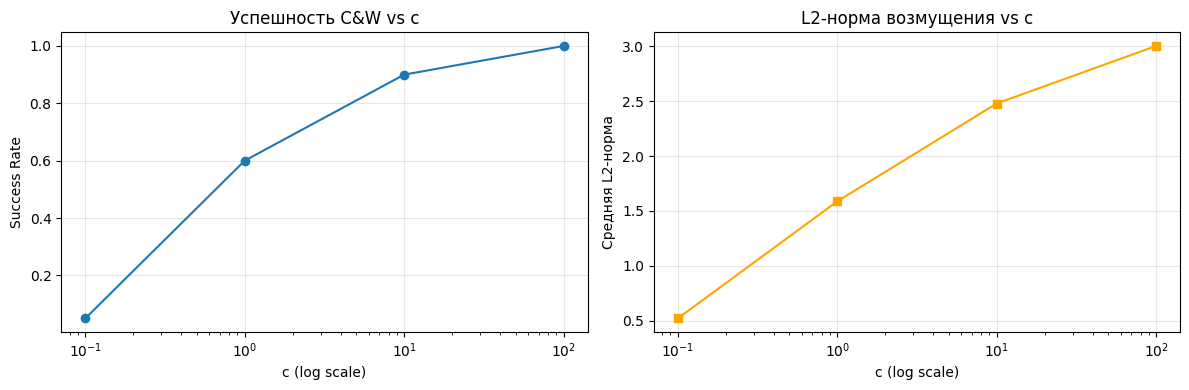

In [25]:
#C4
C_VALUES = [0.1, 1.0, 10.0, 100.0]
N_TEST = 20

# Собираем примеры
x_list = []
y_list = []
for x_batch, y_batch in test_loader:
    x_list.append(x_batch)
    y_list.append(y_batch)
    if sum(t.size(0) for t in x_list) >= N_TEST:
        break
x_eval = torch.cat(x_list, dim=0)[:N_TEST].to(device)
y_eval = torch.cat(y_list, dim=0)[:N_TEST].to(device)

# Для каждого c считаем success rate и среднюю L2
success_rates = []
mean_l2 = []

for c in C_VALUES:
    successes = 0
    l2_sum = 0.0
    for i in range(N_TEST):
        xi = x_eval[i:i+1]
        yi = y_eval[i:i+1].item()
        target = (yi + 1) % 10
        # C&W с текущим c
        x_cw = cw_l2_attack(model, xi, target, c=c, kappa=0.0,
                             num_steps=300, learning_rate=0.01)
        l2 = ((x_cw - xi) ** 2).sum().sqrt().item()
        l2_sum += l2
        with torch.no_grad():
            pred = model(x_cw).argmax(1).item()
        if pred == target:
            successes += 1
    success_rates.append(successes / N_TEST)
    mean_l2.append(l2_sum / N_TEST)
    print(f"c={c}: success={success_rates[-1]:.3f}, mean L2={mean_l2[-1]:.4f}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(C_VALUES, success_rates, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('c (log scale)')
axes[0].set_ylabel('Success Rate')
axes[0].set_title('Успешность C&W vs c')
axes[0].grid(alpha=0.3)

axes[1].plot(C_VALUES, mean_l2, marker='s', color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('c (log scale)')
axes[1].set_ylabel('Средняя L2-норма')
axes[1].set_title('L2-норма возмущения vs c')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 С ростом c успешность атаки увеличивается, но и средняя L2-норма возмущения тоже растёт. Это классический компромисс: параметр c балансирует два слагаемых в целевой функции C&W. При малых c оптимизатор больше заботится о минимальности искажения, чем о победе над моделью, поэтому атака часто проваливается. При больших c приоритет смещается в сторону уверенности в целевом классе — атака срабатывает почти всегда, но ценой заметно большего возмущения.


---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
